In [1]:
import pandas as pd

# dados provenientes de sensores
dados_sensor = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=5, freq='min'),
    'temperatura': [100, 101, 102, 103, 104]
})

# dados provenientes do sistema de produção
dados_producao = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=5, freq='min'),
    'producao': [10, 11, 10, 12, 11]
})

# integração dos dados com base no tempo
dados_integrados = pd.merge(dados_sensor, dados_producao, on='timestamp')

print(dados_integrados)

            timestamp  temperatura  producao
0 2025-01-01 00:00:00          100        10
1 2025-01-01 00:01:00          101        11
2 2025-01-01 00:02:00          102        10
3 2025-01-01 00:03:00          103        12
4 2025-01-01 00:04:00          104        11


In [5]:
import sqlite3
import pandas as pd

# criação de dados simulados
dados = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=10, freq='min'),
    'temperatura': [70,71,72,73,74,75,76,77,78,79]
})

# conexão com banco de dados
conn = sqlite3.connect('historian.db')

# armazenamento dos dados
dados.to_sql('dados_temperatura', conn, if_exists='replace', index=False)

print("Dados armazenados no historiador.")

Dados armazenados no historiador.


In [6]:
import pandas as pd

# Recuperação dos dados do banco SQLite
dados_recuperados = pd.read_sql_query("SELECT * FROM dados_temperatura", conn)

print("Dados recuperados do historiador:")
print(dados_recuperados)

Dados recuperados do historiador:
             timestamp  temperatura
0  2025-01-01 00:00:00           70
1  2025-01-01 00:01:00           71
2  2025-01-01 00:02:00           72
3  2025-01-01 00:03:00           73
4  2025-01-01 00:04:00           74
5  2025-01-01 00:05:00           75
6  2025-01-01 00:06:00           76
7  2025-01-01 00:07:00           77
8  2025-01-01 00:08:00           78
9  2025-01-01 00:09:00           79


In [9]:
import pandas as pd

dados_tags = pd.DataFrame({
    'tag': ['Motor1.Temperatura', 'Motor1.Vibracao', 'Motor2.Temperatura'],
    'valor': [75.2, 0.03, 80.1],
    'timestamp': pd.date_range('2025-01-01', periods=3, freq='min')
})

print(dados_tags)

                  tag  valor           timestamp
0  Motor1.Temperatura  75.20 2025-01-01 00:00:00
1     Motor1.Vibracao   0.03 2025-01-01 00:01:00
2  Motor2.Temperatura  80.10 2025-01-01 00:02:00


In [8]:
estrutura = {
    "Planta": "Planta_A",
    "Linha": "Linha_1",
    "Equipamento": "Motor_3",
    "Sensor": "Temperatura"
}

print(estrutura)

{'Planta': 'Planta_A', 'Linha': 'Linha_1', 'Equipamento': 'Motor_3', 'Sensor': 'Temperatura'}


In [10]:
dados_contextualizados = pd.DataFrame({
    'timestamp': pd.date_range('2025-01-01', periods=3, freq='min'),
    'temperatura': [75, 76, 77],
    'linha': ['Linha_1', 'Linha_1', 'Linha_1'],
    'produto': ['Produto_A', 'Produto_A', 'Produto_B']
})

print(dados_contextualizados)

            timestamp  temperatura    linha    produto
0 2025-01-01 00:00:00           75  Linha_1  Produto_A
1 2025-01-01 00:01:00           76  Linha_1  Produto_A
2 2025-01-01 00:02:00           77  Linha_1  Produto_B


In [12]:
usuarios = {
    "operador": ["visualizar_dados"],
    "engenheiro": ["visualizar_dados", "analisar_dados"],
    "administrador": ["visualizar_dados", "analisar_dados", "modificar_dados"]
}

def verifica_permissao(usuario, acao):
    if acao in usuarios.get(usuario, []):
        return f"Usuário {usuario}: Permissão concedida"
    else:
        return f"Usuário {usuario}: Permissão negada"

usuario = "operador"
print(verifica_permissao(usuario, "modificar_dados"))

usuario = "administrador"
print(verifica_permissao(usuario, "modificar_dados"))

Usuário operador: Permissão negada
Usuário administrador: Permissão concedida


In [14]:
import pandas as pd

dados = pd.DataFrame({
    "timestamp": pd.date_range("2025-01-01", periods=3, freq="min"),
    "temperatura": [75, 76, 77],
    "sensor": ["Sensor_A", "Sensor_A", "Sensor_A"],
    "origem": ["PLC_1", "PLC_1", "PLC_1"]
})

print(dados)

            timestamp  temperatura    sensor origem
0 2025-01-01 00:00:00           75  Sensor_A  PLC_1
1 2025-01-01 00:01:00           76  Sensor_A  PLC_1
2 2025-01-01 00:02:00           77  Sensor_A  PLC_1


In [ ]:
import requests

# dados simulados criados em mockapi.io para 
# exemplificar a integração com uma API industrial.

response = requests.get("https://699a5633377ac05ce28db830.mockapi.io/api/v1/status")
dados = response.json()
print(dados)
print(f"Vibração: {dados[0]['vibracao_rms']}")

[{'id': 1, 'temperatura': 25.3, 'vibracao_rms': 0.023, 'pressao': 5.2, 'bomba_status': True, 'timestamp': '2025-02-21T22:00:00Z'}]
Vibração: 0.023


In [2]:
import paho.mqtt.client as mqtt

# criação do cliente MQTT
client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)

# conexão com o broker
client.connect("broker.hivemq.com", 1883, 60)

# publicação de dados
client.publish("industria/sensor/temperatura", "75")

print("Dados enviados via MQTT")

Dados enviados via MQTT


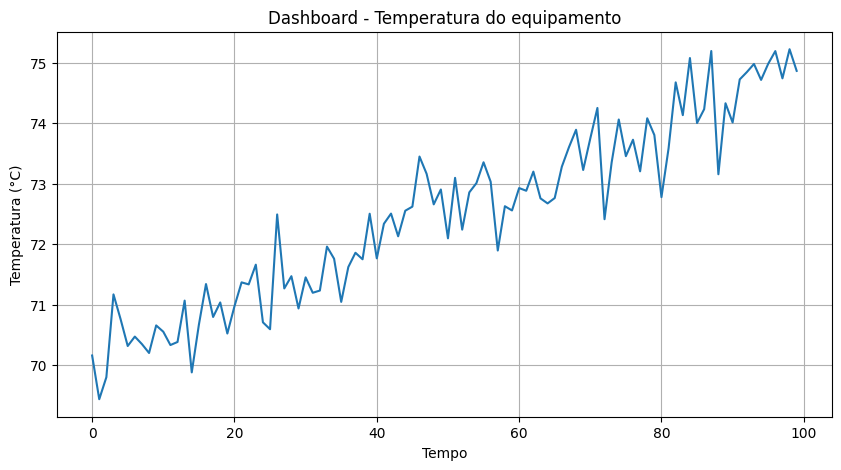

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# simulação de dados
tempo = np.arange(0, 100)
temperatura = 70 + 0.05 * tempo + np.random.normal(0, 0.5, len(tempo))

plt.figure(figsize=(10,5))
plt.plot(tempo, temperatura)
plt.title("Dashboard - Temperatura do equipamento")
plt.xlabel("Tempo")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

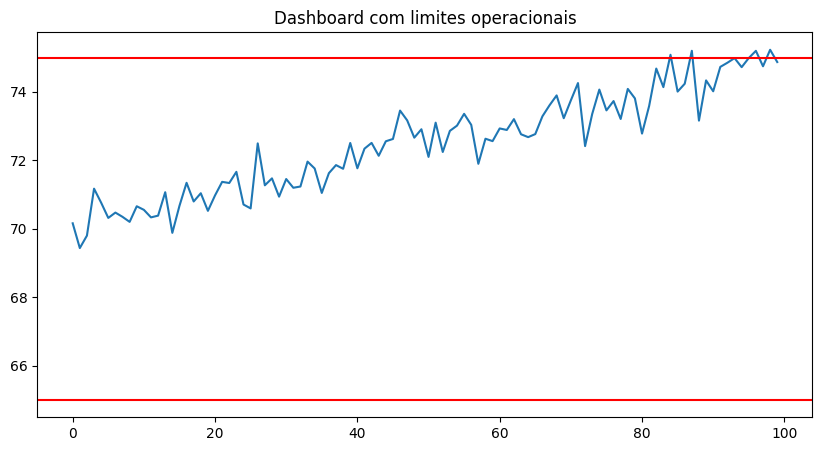

In [5]:
limite_superior = 75
limite_inferior = 65

plt.figure(figsize=(10,5))
plt.plot(temperatura)
plt.axhline(limite_superior, color='red')
plt.axhline(limite_inferior, color='red')
plt.title("Dashboard com limites operacionais")
plt.show()

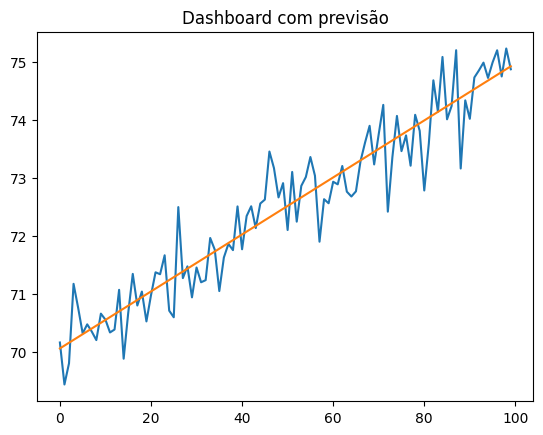

In [6]:
from sklearn.linear_model import LinearRegression

tempo = tempo.reshape(-1,1)

modelo = LinearRegression()
modelo.fit(tempo, temperatura)

previsao = modelo.predict(tempo)

plt.plot(tempo, temperatura)
plt.plot(tempo, previsao)
plt.title("Dashboard com previsão")
plt.show()

In [8]:
import numpy as np
import plotly.graph_objects as go

# simulação de dados industriais
tempo = np.arange(0, 100)
temperatura = 70 + 0.1 * tempo + np.random.normal(0, 0.5, len(tempo))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tempo,
    y=temperatura,
    mode='lines',
    name='Temperatura'
))

fig.update_layout(
    title="Dashboard Industrial - Monitoramento de Temperatura",
    xaxis_title="Tempo",
    yaxis_title="Temperatura (°C)"
)

fig.show()